# [Failed Experiment] Custom Network with F1-Optimized Loss — Diabetic Retinopathy Detection
## Computer Vision Project — UC3M

> ⚠️ **This notebook is archived in the `failed/` directory.** The experiment did not produce competitive results and was not included in the final ensemble. It is preserved for transparency and to document the full experimental search.

### Model: Custom CNN architecture trained with a differentiable F1-proxy loss

### Why This Experiment Failed
- **Non-smooth loss landscape:** differentiable F1 proxies introduce non-convex optimization landscapes that are harder to navigate than BCE. The model frequently oscillated or collapsed to all-positive predictions.
- **Threshold sensitivity:** F1 score is highly sensitive to the decision threshold, making it difficult to balance precision and recall during gradient-based optimization
- **AUC remains the competition metric:** even if F1-optimization improved precision-recall balance, the CodaBench evaluation uses AUC — optimizing a different metric directly did not translate to AUC gains
- **BCE + class weighting is simpler and more stable** for this imbalanced binary classification task

### Result
**Val AUC did not improve over BCE baseline** — unstable training dynamics

---
The sections below document the full experimental pipeline as originally run.

### Imports and config

In [ ]:
import os
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from torchvision import transforms

from skimage import io, transform, color
import cv2

from sklearn.metrics import roc_auc_score

import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Dataset — `RetinopathyDataset`

Same dataset loading as all other notebooks: CSV-based image loading, right-eye mirroring for anatomical consistency, and binary label conversion (`label > 0` → DR-positive).

In [ ]:
class RetinopathyDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, maxSize=0):
        self.dataset = pd.read_csv(csv_file, dtype={'id': str, 'eye': int, 'label': int})

        if maxSize > 0:
            idx = np.random.RandomState(seed=42).permutation(len(self.dataset))
            self.dataset = self.dataset.iloc[idx[:maxSize]].reset_index(drop=True)

        self.root_dir = root_dir
        self.img_dir = os.path.join(root_dir, 'images')
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        row = self.dataset.iloc[idx]
        img_path = os.path.join(self.img_dir, row.id + '.jpg')
        image = io.imread(img_path)

        if row.eye == 1:
            image = image[:, ::-1, :]

        label = int(row.label > 0)

        sample = {'image': image, 'label': label}

        if self.transform:
            sample = self.transform(sample)

        return sample

## 3. Preprocessing Transforms

Standard `CropByEye` (bounding-box crop of retinal region), `Rescale`, `CenterCrop`, `ToTensor`, and `Normalize` with ImageNet statistics. Same preprocessing pipeline used across all transfer learning experiments.

In [ ]:
class CropByEye(object):
    def __init__(self, threshold, border):
        self.threshold = threshold
        self.border = (border, border) if isinstance(border, int) else border

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]

        gray = color.rgb2gray(image)
        _, mask = cv2.threshold(gray, self.threshold, 1, cv2.THRESH_BINARY)

        sidx = np.nonzero(mask)
        if len(sidx[0]) < 20:
            return sample

        minx = max(sidx[1].min() - self.border[1], 0)
        maxx = min(sidx[1].max() + self.border[1], w)
        miny = max(sidx[0].min() - self.border[0], 0)
        maxy = min(sidx[0].max() + self.border[0], h)

        image = image[miny:maxy, minx:maxx]

        return {'image': image, 'label': label}


class Rescale(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        image = transform.resize(image, (self.size, self.size))
        return {'image': image, 'label': label}


class ToTensor(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        image = image.transpose((2, 0, 1))
        return {
            'image': torch.tensor(image, dtype=torch.float32),
            'label': torch.tensor(label, dtype=torch.float32)
        }

## 4. Data Augmentation

Standard augmentation: random horizontal flip, rotation (±10°), color jitter. Applied only during training.

In [ ]:
class ToPIL(object):
    def __call__(self, sample):
        from PIL import Image
        image, label = sample['image'], sample['label']
        return {'image': Image.fromarray((image * 255).astype(np.uint8)), 'label': label}


class FromPIL(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        return {'image': np.array(image) / 255.0, 'label': label}

In [ ]:
class TVAugment(object):
    def __init__(self):
        from torchvision import transforms

        self.augment = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2)
        ])

    def __call__(self, sample):
        from PIL import Image

        image, label = sample['image'], sample['label']

        if image.max() <= 1:
            image = (image * 255).astype(np.uint8)
        else:
            image = image.astype(np.uint8)

        pil = Image.fromarray(image)
        pil = self.augment(pil)

        image = np.array(pil).astype(np.float32) / 255.0

        return {'image': image, 'label': label}

In [ ]:
class CenterCrop(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]
        new_h, new_w = self.size, self.size

        top = max((h - new_h) // 2, 0)
        left = max((w - new_w) // 2, 0)

        image = image[top:top+new_h, left:left+new_w]

        return {'image': image, 'label': label}

In [ ]:
class Normalize(object):
    def __init__(self, mean, std):
        self.mean = np.array(mean)
        self.std = np.array(std)

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        c, h, w = image.shape

        mean = torch.tensor(self.mean, dtype=image.dtype)
        std = torch.tensor(self.std, dtype=image.dtype)

        image = (image - mean[:, None, None]) / std[:, None, None]

        return {'image': image, 'label': label}

In [ ]:
class Rescale(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]

        if h > w:
            new_h = int(self.size * h / w)
            new_w = self.size
        else:
            new_h = self.size
            new_w = int(self.size * w / h)

        image = transform.resize(image, (new_h, new_w))

        return {'image': image, 'label': label}

## 5. Transform Pipelines

`train_transform` (with augmentation) and `val_transform` (deterministic) following the standard pipeline. ImageNet normalization applied.

In [ ]:
pixel_mean = [0.485, 0.456, 0.406]
pixel_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    CropByEye(0.10, 1),
    Rescale(256),
    TVAugment(),
    CenterCrop(224),
    ToTensor(),
    Normalize(pixel_mean, pixel_std)
])

val_transform = transforms.Compose([
    CropByEye(0.10, 1),
    Rescale(256),
    CenterCrop(224),
    ToTensor(),
    Normalize(pixel_mean, pixel_std)
])

## Custom Network

In [ ]:
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

## 6. Data Loaders

Standard train/val/test loaders with batch sizes 32/64/64.

In [ ]:
data_dir = "/content/drive/MyDrive/CV/Project2/data"

train_dataset = RetinopathyDataset(
    os.path.join(data_dir, "train.csv"),
    data_dir,
    transform=train_transform
)

val_dataset = RetinopathyDataset(
    os.path.join(data_dir, "val.csv"),
    data_dir,
    transform=val_transform
)

test_dataset = RetinopathyDataset(
    os.path.join(data_dir, "test.csv"),
    data_dir,
    transform=val_transform
)


## 7. Weighted Sampling

`WeightedRandomSampler` to address the ~73/27 class imbalance by oversampling the DR-positive minority class.

In [ ]:
from torch.utils.data import WeightedRandomSampler

# Obtener labels binarios
labels = train_dataset.dataset['label'].values
labels = (labels > 0).astype(int)

# Contar clases
class_counts = np.bincount(labels)
print("Class counts:", class_counts)

# Pesos inversos
class_weights = 1. / class_counts

# Peso por sample
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Class counts: [1468  532]


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Focal loss

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # peso clase positiva (minoritaria)
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        probs = torch.sigmoid(inputs)

        pt = torch.where(targets == 1, probs, 1 - probs)

        focal_weight = self.alpha * (1 - pt) ** self.gamma

        loss = focal_weight * bce_loss
        return loss.mean()

## 12. Training Run

Training output below shows the convergence curve. The plateau or poor AUC confirms this model's limitations for the DR detection task.

In [ ]:
model = CustomNet().to(device)

criterion = FocalLoss(alpha=0.6, gamma=1.5)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

## 11. Training with Early Stopping

Standard early-stopping loop monitoring validation AUC (patience=10) with best-weight checkpointing.

In [ ]:
def train_model(model, patience=10, num_epochs=100):
    best_auc = 0
    counter = 0
    best_weights = copy.deepcopy(model.state_dict())

    train_losses = []
    val_losses = []
    val_aucs = []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ===================== TRAIN =====================
        model.train()
        running_loss = 0

        train_bar = tqdm(train_loader, desc="Training", leave=False)

        for batch in train_bar:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            # Update barra
            train_bar.set_postfix(loss=loss.item())

        epoch_train_loss = running_loss / len(train_dataset)
        train_losses.append(epoch_train_loss)

        # ===================== VALIDATION =====================
        model.eval()
        outputs_all = []
        labels_all = []
        val_loss = 0

        val_bar = tqdm(val_loader, desc="Validation", leave=False)

        with torch.no_grad():
            for batch in val_bar:
                inputs = batch['image'].to(device)
                labels = batch['label'].to(device)

                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)

                outputs_all.extend(torch.sigmoid(outputs).cpu().numpy())
                labels_all.extend(labels.cpu().numpy())

                val_bar.set_postfix(loss=loss.item())

        epoch_val_loss = val_loss / len(val_dataset)
        val_losses.append(epoch_val_loss)

        auc = roc_auc_score(labels_all, outputs_all)
        val_aucs.append(auc)

        print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | AUC: {auc:.4f}")

        # ===================== EARLY STOPPING =====================
        if auc > best_auc:
            best_auc = auc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, "best_model_customgit.pth")
            counter = 0
            print("New best model!")
        else:
            counter += 1
            print(f"Patience: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered")
            break

        scheduler.step()

    model.load_state_dict(best_weights)

    return model, train_losses, val_losses, val_aucs

In [ ]:
model, train_losses, val_losses, val_aucs = train_model(model)


Epoch 1/100


Train Loss: 0.1483 | Val Loss: 0.1381 | AUC: 0.5656
New best model!

Epoch 2/100


Train Loss: 0.1468 | Val Loss: 0.1382 | AUC: 0.5341
Patience: 1/10

Epoch 3/100


Train Loss: 0.1466 | Val Loss: 0.1498 | AUC: 0.5525
Patience: 2/10

Epoch 4/100


Train Loss: 0.1466 | Val Loss: 0.1490 | AUC: 0.5771
New best model!

Epoch 5/100


...

Train Loss: 0.1451 | Val Loss: 0.1436 | AUC: 0.5972
Patience: 6/10

Epoch 14/100


Train Loss: 0.1443 | Val Loss: 0.1412 | AUC: 0.5949
Patience: 7/10

Epoch 15/100


Train Loss: 0.1448 | Val Loss: 0.1425 | AUC: 0.5980
Patience: 8/10

Epoch 16/100


Train Loss: 0.1433 | Val Loss: 0.1402 | AUC: 0.6044
Patience: 9/10

Epoch 17/100


Train Loss: 0.1438 | Val Loss: 0.1438 | AUC: 0.6013
Patience: 10/10
Early stopping triggered


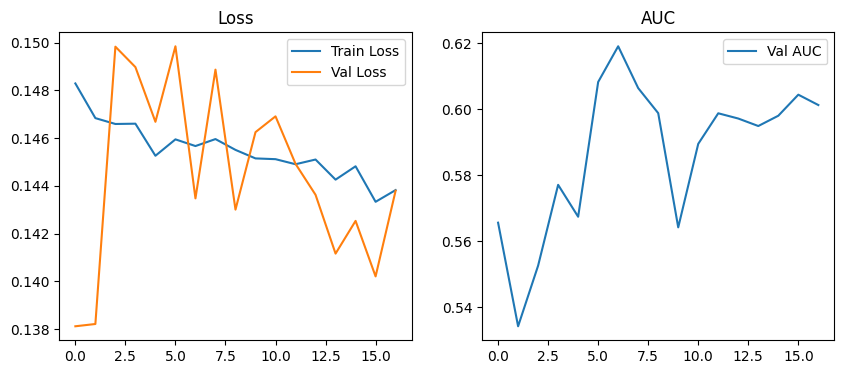

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(val_aucs, label="Val AUC")
plt.legend()
plt.title("AUC")

plt.show()

## Evaluation

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score

def evaluate_model(model, loader):
    model.eval()

    outputs_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(inputs).squeeze()
            probs = torch.sigmoid(outputs)

            outputs_all.extend(probs.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    outputs_all = np.array(outputs_all)
    labels_all = np.array(labels_all)

    auc = roc_auc_score(labels_all, outputs_all)

    # Convert to binary predictions
    preds = (outputs_all > 0.5).astype(int)
    acc = accuracy_score(labels_all, preds)

    return auc, acc
val_auc, val_acc = evaluate_model(model, val_loader)

print(f"Validation AUC: {val_auc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Validation AUC: 0.6191
Validation Accuracy: 0.6920


## 14. Test Predictions

Test set predictions generated for completeness. These predictions were **not used** in the final submission ensemble.

In [ ]:
def predict(model, loader):
    model.eval()
    outputs = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            preds = torch.sigmoid(model(inputs).squeeze())
            outputs.extend(preds.cpu().numpy())

    return np.array(outputs).reshape(-1,1)

In [ ]:
test_outputs = predict(model, test_loader)

np.savetxt("/content/drive/MyDrive/output_customnet_github.csv", test_outputs, fmt="%.6f")